In [ ]:
!pip install scikit-learn==1.8.0

In [ ]:
import pandas as pd
import numpy as np
import os, kagglehub

import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

⬆These are all the necessary libraries used in the rest of the code/
program.⬆

#Data loading:

In [ ]:
path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")

print("Path to dataset files:", path)
print(os.listdir(path))

Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.
Path to dataset files: /kaggle/input/ibm-hr-analytics-attrition-dataset
['WA_Fn-UseC_-HR-Employee-Attrition.csv']


⬆Download latest version of the dataset directly from Kaggle and see the file name.⬆

In [ ]:
df = pd.read_csv(os.path.join(path, "WA_Fn-UseC_-HR-Employee-Attrition.csv"))
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


⬆After loading the data and inspecting it, we observe that it has 1470 rows & 35 columns. There are no null entries.⬆

#Now let us explore the dataset.
**\#1 What is the overall attrition rate?**

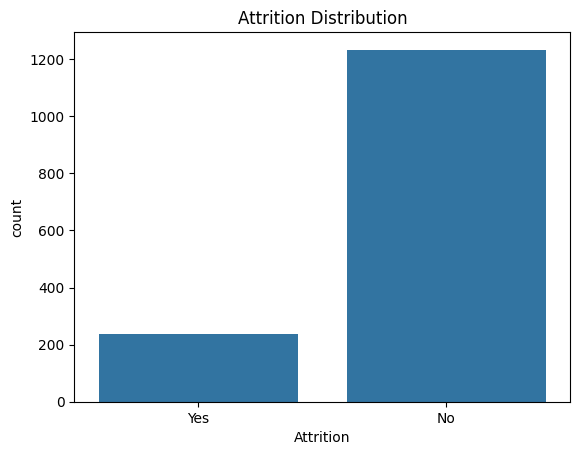

,proportion
Attrition,
No,0.838776
Yes,0.161224


In [ ]:
sns.countplot(x="Attrition", data=df)
plt.title("Attrition Distribution")
plt.show()

df["Attrition"].value_counts(normalize=True)

\>We observe that approximately 16% of employees have left the company. The dataset shows moderate class imbalance, which may influence model performance and evaluation strategy.

>This establishes the baseline turnover level within the organization.

**\#2 Does income influence attrition?**

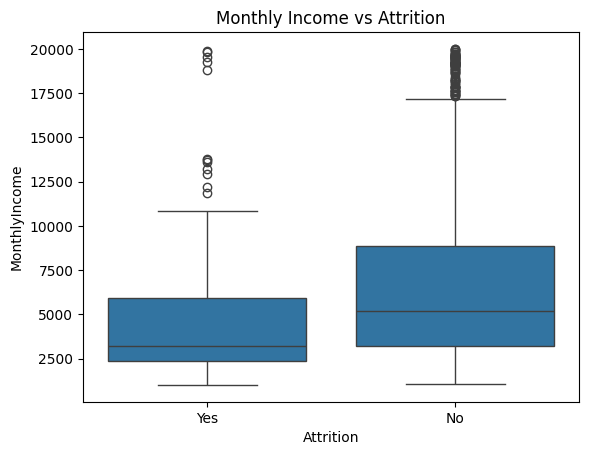

In [ ]:
sns.boxplot(x="Attrition", y="MonthlyIncome", data=df)
plt.title("Monthly Income vs Attrition")
plt.show()

\>The plot shows that employees who left tend to have a lower median income compared to those who stayed.
>This suggests compensation may be a contributing factor to turnover.

**\#3 Does overtime increase attrition risk?**

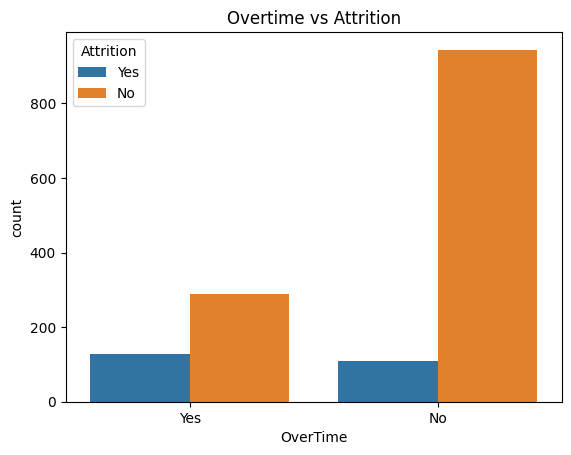

In [ ]:
sns.countplot(x="OverTime", hue="Attrition", data=df)
plt.title("Overtime vs Attrition")
plt.show()

\>A noticeably higher proportion of employees working overtime have left the company. Approximately one-third of employees working overtime leave the company, compared to a substantially lower proportion among those who do not work overtime.
>This implies workload and work-life balance strongly influence retention.

**\#4 Does tenure affect attrition?**

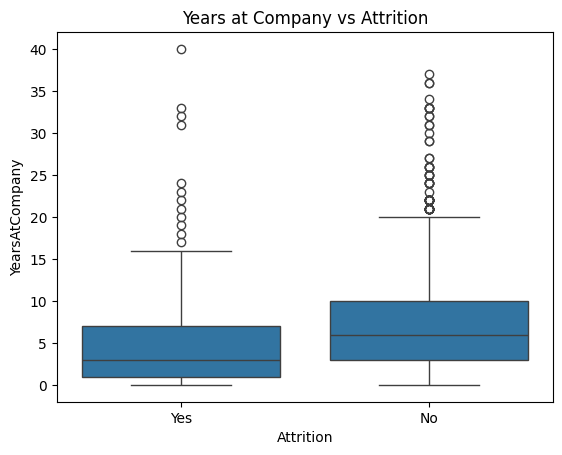

In [ ]:
sns.boxplot(x="Attrition", y="YearsAtCompany", data=df)
plt.title("Years at Company vs Attrition")
plt.show()

\>Employees who left the company tend to have a lower median tenure compared to those who stayed. Attrition appears concentrated in the early years of employment.
>This suggests early-career retention and onboarding experience may significantly influence turnover risk.

**#5 Which departments experience higher turnover?**

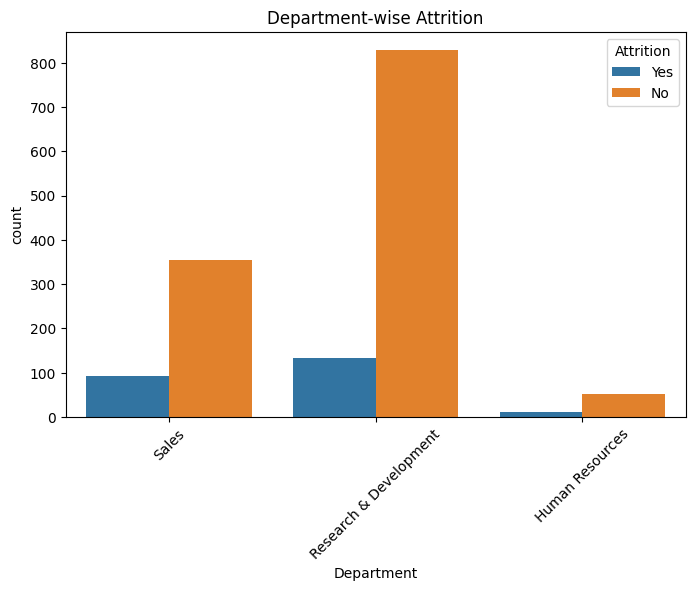

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x="Department", hue="Attrition", data=df)
plt.xticks(rotation=45)
plt.title("Department-wise Attrition")
plt.show()

The counts may not be clear due to difference in their sizes. Let's plot percentages.

In [ ]:
df_encoded = df.copy()
df_encoded["Attrition"] = df_encoded["Attrition"].map({"Yes": 1, "No": 0})
dept_attrition = (
    df_encoded.groupby("Department")["Attrition"]
    .mean()
    .sort_values(ascending=False)
)
dept_attrition_percent = dept_attrition * 100
dept_attrition_percent

,Attrition
Department,
Sales,20.627803
Human Resources,19.047619
Research & Development,13.839750


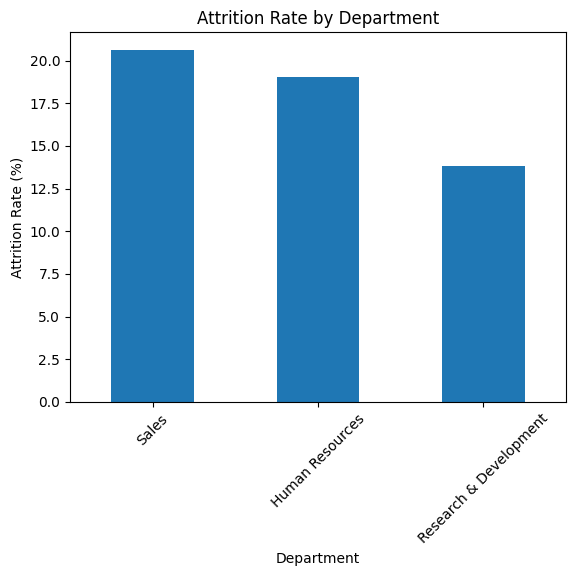

In [ ]:
dept_attrition_percent.plot(kind="bar")
plt.ylabel("Attrition Rate (%)")
plt.title("Attrition Rate by Department")
plt.xticks(rotation=45)
plt.show()

\>Attrition rates vary noticeably across departments.
Sales exhibits the highest attrition rate at approximately 20.6%, followed closely by Human Resources at 19.0%.
Research & Development shows a comparatively lower rate of 13.8%.

*Although Research & Development has the highest number of employees, its attrition rate is significantly lower than Sales and HR, indicating stronger retention within that department relative to its size.*
>This suggests turnover is not evenly distributed and may be influenced by department-specific pressures, such as performance targets in Sales or role dynamics within HR.

**#6 Are job satisfaction levels linked to attrition?**

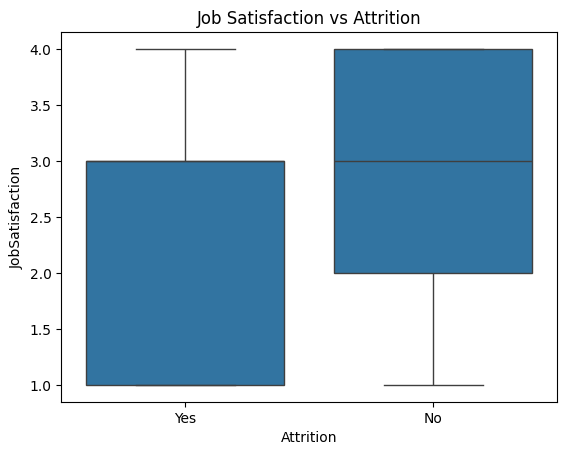

In [ ]:
sns.boxplot(x="Attrition", y="JobSatisfaction", data=df)
plt.title("Job Satisfaction vs Attrition")
plt.show()

\>Lower job satisfaction scores appear associated with higher attrition rates. Employees with higher job satisfaction scores demonstrate noticeably lower attrition rates.
>This reinforces the importance of employee engagement initiatives.

#Summary:

The exploratory analysis reveals several meaningful patterns associated with employee attrition.

The overall attrition rate stands at approximately 16%, indicating moderate class imbalance. While not extreme, this imbalance should be considered during model evaluation.

Compensation appears to influence turnover, as employees who left the organization tend to have lower median monthly incomes compared to those who remained.

Overtime shows a strong relationship with attrition. Employees working overtime leave at a significantly higher rate, suggesting workload and work-life balance may be key retention factors.

Tenure also plays a notable role, with attrition appearing more concentrated in the early years of employment. This may indicate onboarding challenges or early-career disengagement.

Departmental analysis shows that attrition is not evenly distributed. Sales and Human Resources demonstrate higher attrition rates compared to Research & Development, highlighting potential department-specific pressures.

Finally, job satisfaction displays a clear inverse relationship with attrition, reinforcing the importance of employee engagement and workplace experience in retention outcomes.

These findings provide direction for predictive modeling, particularly highlighting Overtime, Monthly Income, Years at Company, Department, and Job Satisfaction as potentially influential predictors.



#Data cleaning & Encoding:

In [ ]:
df.drop(["EmployeeNumber", "EmployeeCount", "Over18", "StandardHours",
         "HourlyRate", "DailyRate", "MonthlyRate"], axis=1, inplace=True)

⬆Columns that are identifiers & redundant, are removed from cluttering the dataset.⬆

In [ ]:
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

⬆Convert the target Attrition into numbers, i.e., encode Attrition as 1 (Yes) and 0 (No).⬆

In [ ]:
df = pd.get_dummies(df, drop_first=True)

⬆Categorical variables are transformed using One-Hot Encoding to allow machine learning models to process them.⬆

In [ ]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

⬆The target column is separated from the rest.⬆

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
    random_state=42, stratify=y
)

⬆Split the data into Train & Test sets.⬆

#Base model building:

In [ ]:
model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [ ]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7789115646258503

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.79      0.86       247
           1       0.39      0.70      0.50        47

    accuracy                           0.78       294
   macro avg       0.66      0.75      0.68       294
weighted avg       0.85      0.78      0.80       294


Confusion Matrix:
 [[196  51]
 [ 14  33]]


The baseline Logistic Regression model achieved an accuracy of 77%.
More importantly, it achieved a recall of 70% for the attrition class, meaning it successfully identified the majority of employees who left.

While precision for attrition is relatively low (39%), this tradeoff is acceptable in an HR context, where failing to identify at-risk employees may be more costly than incorrectly flagging some who ultimately stay.

#Baseline Feature Importance Extraction:

In [ ]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients = coefficients.sort_values(by="Coefficient", ascending=False)

coefficients.head()

,Feature,Coefficient
40,OverTime_Yes,1.813713
10,PerformanceRating,0.989667
31,JobRole_Laboratory Technician,0.972391
20,BusinessTravel_Travel_Frequently,0.964925
39,MaritalStatus_Single,0.684462


**Strongest Predictors Increasing Attrition Risk**

1. OverTime_Yes (1.81):
Overtime is the most influential predictor of attrition, strongly reinforcing workload as a critical retention factor.

2. PerformanceRating (0.99):
Higher performance ratings are associated with increased attrition risk, possibly reflecting greater external job opportunities or unmet advancement expectations.

3. JobRole_Laboratory Technician (0.97):
This role shows elevated turnover risk, suggesting role-specific dissatisfaction or limited growth pathways.

4. BusinessTravel_Travel_Frequently (0.96):
Frequent travel is associated with higher attrition, likely due to burnout or work-life strain.

5. MaritalStatus_Single (0.68):
Single employees appear more mobile and therefore more likely to leave.

In [ ]:
coefficients.sort_values(by="Coefficient").head()

,Feature,Coefficient
35,JobRole_Research Scientist,-0.394204
4,JobInvolvement,-0.341713
3,EnvironmentSatisfaction,-0.336424
6,JobSatisfaction,-0.327993
27,EducationField_Other,-0.270536


**Strongest Retention Drivers**

1. JobInvolvement (-0.34):
Higher engagement significantly reduces attrition risk.

2. EnvironmentSatisfaction (-0.34):
Positive work environments improve retention.

3. JobSatisfaction (-0.33):
Greater job satisfaction lowers attrition likelihood.

4. JobRole_Research Scientist (-0.39):
Research Scientists demonstrate stronger retention relative to other roles.

5. EducationField_Other (-0.27):
Certain educational backgrounds appear associated with lower turnover.

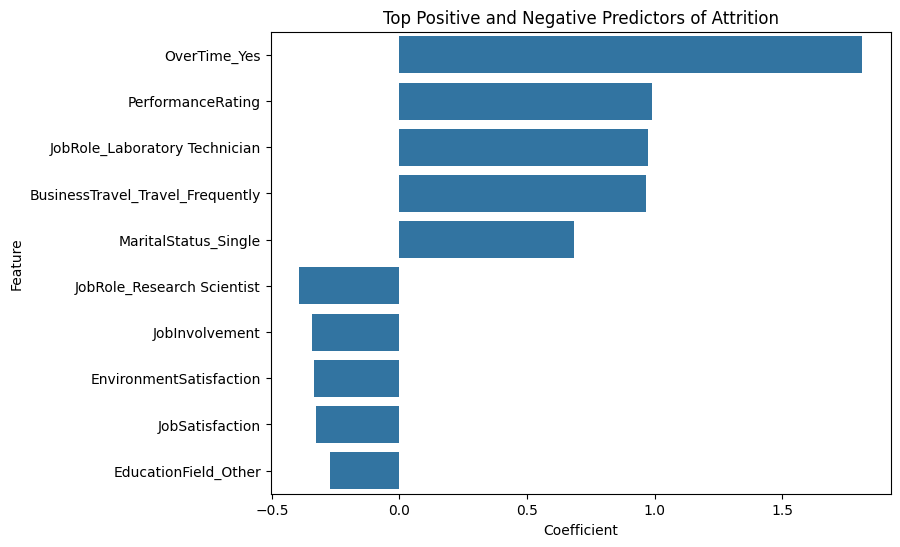

In [ ]:
top_features = pd.concat([
    coefficients.head(5),
    coefficients.sort_values(by="Coefficient").head(5)
])

plt.figure(figsize=(8,6))
sns.barplot(x="Coefficient", y="Feature", data=top_features)
plt.title("Top Positive and Negative Predictors of Attrition")
plt.show()

**Summary**

The Logistic Regression model identifies *Overtime* as the strongest predictor of employee attrition, indicating workload as a critical risk factor. *Performance Rating*, *Frequent Business Travel*, *Marital Status (Single)*, and the role of *Laboratory Technician* are also associated with increased likelihood of leaving.

On the retention side, *Job Involvement*, *Environment Satisfaction*, and *Job Satisfaction* significantly reduce attrition risk. The role of Research Scientist demonstrates comparatively stronger retention.

Overall, the findings suggest that workload management, employee engagement, and role-specific factors play a central role in attrition risk and should be key focus areas for HR intervention.

#Random Forest Model:

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.8401360544217688

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.50      0.09      0.15        47

    accuracy                           0.84       294
   macro avg       0.67      0.53      0.53       294
weighted avg       0.79      0.84      0.79       294


Confusion Matrix:
 [[243   4]
 [ 43   4]]


Although Random Forest achieved higher overall accuracy (83.6%), it performed poorly in identifying attrition cases, achieving a recall of only 9%.

This indicates the model heavily favored predicting non-attrition due to class imbalance.

In contrast, Logistic Regression achieved significantly higher recall (70%) for attrition, making it more suitable for HR intervention purposes where identifying at-risk employees is critical.

#Use SMOTE & try RF again:

In [ ]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

rf_smote_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)
rf_smote_model.fit(X_train_smote, y_train_smote)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
y_pred_rf = rf_smote_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.826530612244898

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.93      0.90       247
           1       0.43      0.28      0.34        47

    accuracy                           0.83       294
   macro avg       0.65      0.60      0.62       294
weighted avg       0.80      0.83      0.81       294


Confusion Matrix:
 [[230  17]
 [ 34  13]]


**After using SMOTE:**

While recall for attrition improved from 9% to 26%, the model still underperformed compared to Logistic Regression, which achieved a substantially higher recall of 70% without resampling.

Although Random Forest with SMOTE maintained a higher overall accuracy (82.3%) than Logistic Regression (77.8%), this was largely driven by strong performance on the majority class (non-attrition). Its ability to correctly identify employees who left remained limited.

Given that attrition detection is the primary business objective, Logistic Regression provides a better balance between precision and recall for the minority class and is therefore the more suitable model for this task.

#Conclusion:

This analysis aimed to identify factors contributing to employee attrition and evaluate predictive modeling approaches. Exploratory analysis revealed that attrition is associated with overtime, lower income, lower job satisfaction, and shorter tenure. Department-wise differences also indicate that Sales and HR experience higher turnover rates compared to Research & Development.

Logistic Regression achieved a recall of 70% for attrition cases, significantly outperforming Random Forest both before (9%) and after SMOTE resampling (26%). Although Random Forest achieved higher overall accuracy (above 82%), it struggled to effectively detect employees who left the company.

Given that identifying at-risk employees is more critical than maximizing overall accuracy, Logistic Regression is the preferred model for this task.

These findings suggest that proactive interventions focusing on workload management, employee satisfaction, and early-career support may help reduce attrition risk.



#Final Model Building:

>Based on the comparative analysis, Logistic Regression was selected as the final model due to its superior recall performance in identifying attrition cases.

In [ ]:
df = pd.read_csv("/kaggle/input/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv")

⬆ The original dataset is reloaded to ensure that the final model pipeline operates on raw, unencoded data. This ensures reproducibility and deployment readiness. ⬆

In [ ]:
df = df.drop(["EmployeeNumber", "EmployeeCount",
              "Over18", "StandardHours",
              "HourlyRate", "DailyRate", "MonthlyRate"], axis=1)

⬆ Identifier and constant-value columns are removed as they do not contribute to predictive performance and may introduce noise. ⬆

In [ ]:
y = df["Attrition"].map({"Yes": 1, "No": 0})
X = df.drop("Attrition", axis=1)

⬆ The target variable (Attrition) is encoded as binary values (1 = Yes, 0 = No) and separated from the feature set. ⬆

In [ ]:
categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(exclude="object").columns

⬆ Feature columns are categorized into numerical and categorical types to apply appropriate preprocessing transformations. ⬆

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"),
        categorical_cols)
    ]
)

pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

⬆ A ColumnTransformer is used to apply One-Hot Encoding to categorical variables while passing numerical variables unchanged.
The preprocessing step and Logistic Regression model are combined into a single Pipeline object, ensuring consistent data transformation during both training and prediction. ⬆

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

⬆ The dataset is split into training and testing sets while preserving the class distribution of attrition. ⬆

In [ ]:
pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

⬆ The pipeline learns preprocessing transformations and model parameters simultaneously. ⬆

In [ ]:
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.79      0.86       247
           1       0.39      0.70      0.50        47

    accuracy                           0.78       294
   macro avg       0.66      0.75      0.68       294
weighted avg       0.85      0.78      0.80       294



⬆ Performance metrics are generated to confirm consistency with previous Logistic Regression results. ⬆

In [ ]:
import pickle

with open("attrition_pipeline.pkl", "wb") as f:
    pickle.dump(pipeline, f)

⬆ The fully trained pipeline is serialized using pickle. This saved object can accept raw employee data and generate attrition risk predictions without requiring manual preprocessing. ⬆